Optimisation protype

Starting HMC with 1000 samples...
Sample 200/1000 | Acceptance Rate: 0.98
Sample 400/1000 | Acceptance Rate: 0.98
Sample 600/1000 | Acceptance Rate: 0.99
Sample 800/1000 | Acceptance Rate: 0.99
Sample 1000/1000 | Acceptance Rate: 0.99

HMC Complete.
Final Acceptance Rate: 0.99

--- Results (Mean of Posterior) ---
True x:     [4.0, 10.0, 16.0, 0.800000011920929, 0.5, 0.8999999761581421]
Estimated x: tensor([ 3.9400, 10.0900, 16.0800,  1.2200,  0.1200,  1.5100])


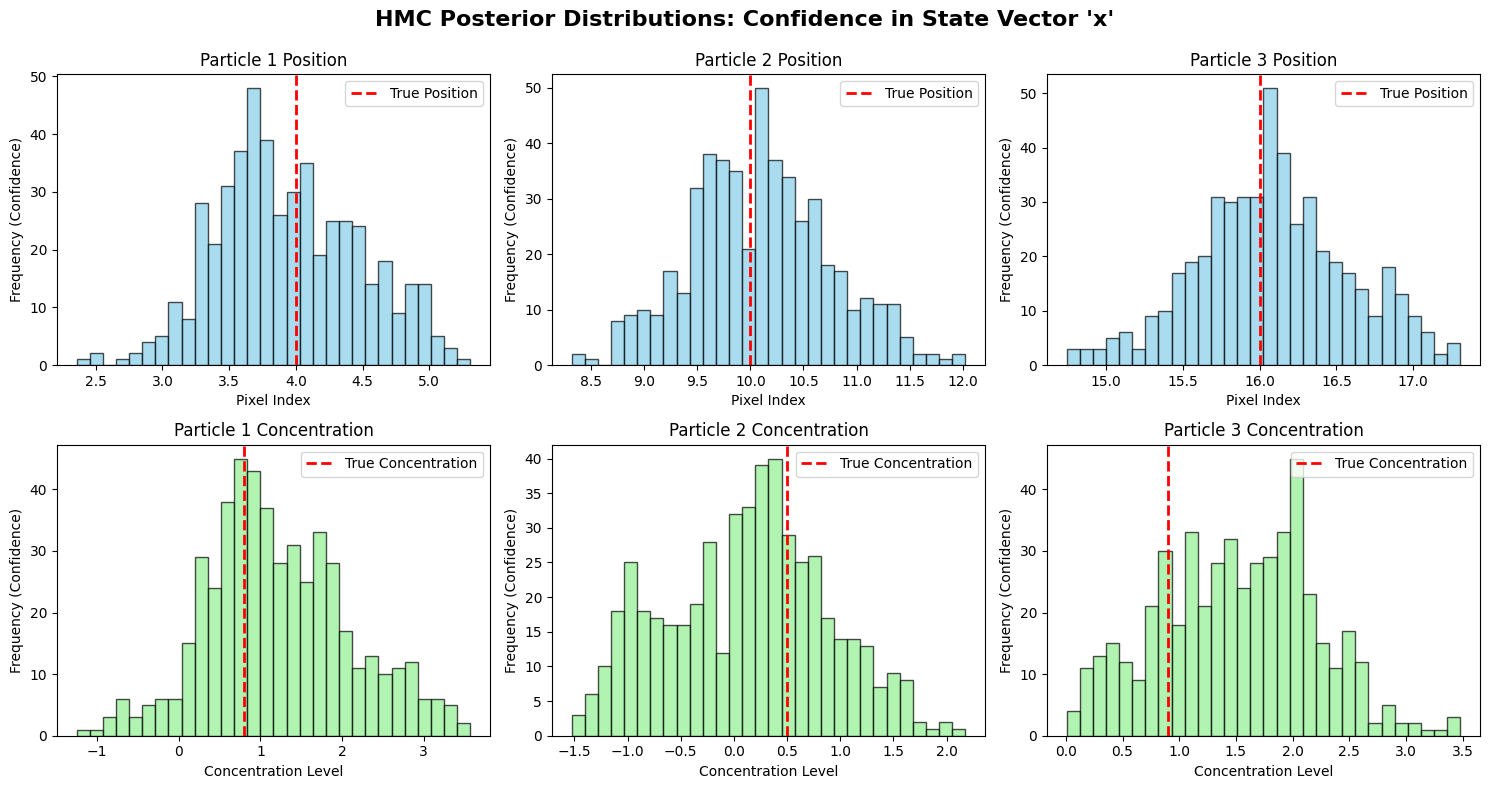

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
# ==========================================
# 1. DUMMY FORWARD MODEL (PyTorch Differentiable)
# ==========================================
def dummy_forward_model(x, grid_size):
    """
    Differentiable PyTorch map A taking state x to image b.
    x: 1D tensor [positions..., concentrations...]
    """
    n_particles = x.shape[0] // 2
    positions = x[:n_particles]
    concentrations = x[n_particles:]
    
    # Create a blank 1D pixel image
    image_b = torch.zeros(grid_size, dtype=torch.float32)
    grid_indices = torch.arange(grid_size, dtype=torch.float32)
    
    for pos, conc in zip(positions, concentrations):
        # Differentiable "soft" assignment using a Gaussian spread
        # This simulates laser spreading and allows gradients to flow back to 'pos'
        spread = torch.exp(-0.5 * ((grid_indices - pos) / 0.8)**2)
        
        # Absolute value ensures concentration is positive for sqrt
        # Small epsilon (1e-6) prevents NaN gradients at exactly zero
        light_contribution = torch.sqrt(torch.abs(conc) + 1e-6) * 1.5
        
        image_b = image_b + (light_contribution * spread)


    return image_b

# ==========================================
# 2. POTENTIAL ENERGY (Negative Log Posterior)
# ==========================================
def potential_energy(x, target_image_b, grid_size):
    """
    In HMC, the objective function is treated as 'Potential Energy'.
    Lower energy = better match = higher probability.
    """
    simulated_image = dummy_forward_model(x, grid_size)
    
    # Calculate the squared L2 Norm (Residual)
    # Equivalent to minimizing ||A(x) - b||_2
    energy = torch.sum((simulated_image - target_image_b)**2)
    return energy
# ==========================================
# 2. HMC LEAPFROG INTEGRATOR
# ==========================================
def leapfrog_step(x, p, epsilon, target_image_b, grid_size):
    """
    Performs one leapfrog step: updating momentum, position, and momentum again.
    """
    x.requires_grad_(True)
    
    # 1. Calculate gradient of potential energy at current position
    U = potential_energy(x, target_image_b, grid_size)
    grad_U = torch.autograd.grad(U, x)[0]
    
    # 2. Half-step update for momentum
    p_half = p - (epsilon / 2) * grad_U
    
    # 3. Full-step update for position (detach to avoid keeping graph history)
    x_new = x.detach() + epsilon * p_half
    x_new.requires_grad_(True)
    
    # 4. Calculate new gradient at new position
    U_new = potential_energy(x_new, target_image_b, grid_size)
    grad_U_new = torch.autograd.grad(U_new, x_new)[0]
    
    # 5. Final half-step update for momentum
    p_new = p_half - (epsilon / 2) * grad_U_new
    
    return x_new.detach(), p_new


def plot_image_comparison(target_tensor, guess_tensor):
    """
    Plots a side-by-side bar chart comparing the target camera image b 
    with the simulated image A(x) from the engine's current state guess.
    """
    # 1. Convert PyTorch tensors to standard Python lists to bypass NumPy errors
    # We use .detach() first to ensure we aren't pulling the gradient history graph into the plot
    target_data = target_tensor.detach().tolist()
    guess_data = guess_tensor.detach().tolist()
    
    # 2. Setup the x-axis pixel indices
    pixels = range(len(target_data))
    
    # 3. Initialize the plot
    plt.figure(figsize=(12, 5))
    
    # 4. Calculate the offset for side-by-side bars
    bar_width = 0.4
    r1 = [p - bar_width/2 for p in pixels]
    r2 = [p + bar_width/2 for p in pixels]
    
    # 5. Plot the target image (blue) and the guess image (orange)
    plt.bar(r1, target_data, color='royalblue', width=bar_width, 
            edgecolor='black', label='Target Image (Ground Truth b)', alpha=0.8)
    
    plt.bar(r2, guess_data, color='darkorange', width=bar_width, 
            edgecolor='black', label='Simulated Guess Image A(x)', alpha=0.8)
    
    # 6. Formatting
    plt.title("Camera Sensor Image Comparison: Target vs. Guess")
    plt.xlabel("Pixel Index")
    plt.ylabel("Light Intensity")
    plt.xticks(pixels) # Ensure every pixel number is labeled
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 7. Display
    plt.tight_layout()
    plt.show()

def plot_posterior_histograms(samples, n_particles=3, burn_in=500, true_x=None):
    """
    Visualises the posterior distribution of the HMC samples.
    Generates subplots of histograms for both particle positions and dye concentrations.
    """
    # 1. Convert samples to a PyTorch tensor and discard the burn-in phase
    samples_tensor = torch.tensor(samples[burn_in:])
    
    # 2. Set up the plot grid (2 rows: Positions on top, Concentrations on bottom)
    fig, axes = plt.subplots(nrows=2, ncols=n_particles, figsize=(15, 8))
    fig.suptitle("HMC Posterior Distributions: Confidence in State Vector 'x'", fontsize=16, fontweight='bold')
    
    for i in range(n_particles):
        # --- Plot Positions (Top Row) ---
        ax_pos = axes[0, i]
        # Extract all sampled positions for particle 'i'
        pos_data = samples_tensor[:, i].tolist()
        
        ax_pos.hist(pos_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        ax_pos.set_title(f"Particle {i+1} Position")
        ax_pos.set_xlabel("Pixel Index")
        ax_pos.set_ylabel("Frequency (Confidence)")
        
        # Overlay the true value if provided
        if true_x is not None:
            ax_pos.axvline(true_x[i].item(), color='red', linestyle='dashed', 
                           linewidth=2, label='True Position')
            ax_pos.legend()
            
        # --- Plot Concentrations (Bottom Row) ---
        ax_conc = axes[1, i]
        # Extract all sampled concentrations for particle 'i' (offset by n_particles)
        conc_data = samples_tensor[:, i + n_particles].tolist()
        
        ax_conc.hist(conc_data, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        ax_conc.set_title(f"Particle {i+1} Concentration")
        ax_conc.set_xlabel("Concentration Level")
        ax_conc.set_ylabel("Frequency (Confidence)")
        
        # Overlay the true value if provided
        if true_x is not None:
            ax_conc.axvline(true_x[i + n_particles].item(), color='red', linestyle='dashed', 
                            linewidth=2, label='True Concentration')
            ax_conc.legend()
            
    # 3. Format and display
    plt.tight_layout()
    # Adjust layout to make room for the main title
    plt.subplots_adjust(top=0.90) 
    plt.show()
# ==========================================
# 3. THE MAIN HMC SAMPLING LOOP
# ==========================================
def run_hmc(true_x, n_samples=1000, leapfrog_steps=10, epsilon=0.01):
    grid_size = 20
    n_particles = 3
    
    # Ground Truth Generation
    
    target_image_b = dummy_forward_model(true_x, grid_size).detach()
    
    # Initial Guess
    current_x = torch.tensor([3.0, 11.0, 15.0, 0.5, 0.5, 0.5])
    
    samples = []
    accepted = 0
    
    print(f"Starting HMC with {n_samples} samples...")
    
    for i in range(n_samples):
        # Sample random initial momentum from a standard Normal distribution
        current_p = torch.randn_like(current_x)
        
        # Save current state to evaluate acceptance later
        x = current_x.clone()
        p = current_p.clone()
        
        # Calculate current total energy: H = U(x) + K(p)
        # K(p) is kinetic energy, usually (1/2) * p^T * p
        U_current = potential_energy(current_x, target_image_b, grid_size).item()
        K_current = 0.5 * torch.sum(current_p**2).item()
        H_current = U_current + K_current
        
        # Perform Leapfrog integration to find proposed state
        for _ in range(leapfrog_steps):
            x, p = leapfrog_step(x, p, epsilon, target_image_b, grid_size)
            
        # Reverse momentum for symmetry in detailed balance (mathematical formality)
        p = -p
        
        # Calculate proposed total energy
        U_proposed = potential_energy(x, target_image_b, grid_size).item()
        K_proposed = 0.5 * torch.sum(p**2).item()
        H_proposed = U_proposed + K_proposed
        
        # Metropolis Acceptance Criterion
        # If the new state has lower energy, it's always accepted.
        # If higher, it's accepted with a probability based on the energy difference.
        acceptance_prob = min(1.0, torch.exp(torch.tensor(H_current - H_proposed)).item())
        
        if torch.rand(1).item() < acceptance_prob:
            current_x = x
            accepted += 1
            
        samples.append(current_x.clone().tolist())
        
        if (i + 1) % 200 == 0:
            print(f"Sample {i+1}/{n_samples} | Acceptance Rate: {accepted/(i+1):.2f}")
            
    print("\nHMC Complete.")
    print(f"Final Acceptance Rate: {accepted/n_samples:.2f}")
    
    # Print the mean of the last 500 samples (the "burn-in" period is skipped)
    samples_tensor = torch.tensor(samples[500:])
    mean_estimate = torch.mean(samples_tensor, dim=0)
    
    print("\n--- Results (Mean of Posterior) ---")
    print("True x:    ", true_x.tolist())
    print("Estimated x:", torch.round(mean_estimate * 100) / 100) # Rounded for clean output
    
    return samples

if __name__ == "__main__":
    # Running the engine with 1000 samples
    true_x = torch.tensor([4.0, 10.0, 16.0, 0.8, 0.5, 0.9])
    samples = run_hmc(true_x, n_samples=1000, leapfrog_steps=15, epsilon=0.015)
    plot_posterior_histograms(samples, n_particles=3, burn_in=500, true_x=true_x)
    # current_guess_image = dummy_forward_model(current_x, grid_size)
    # plot_image_comparison(target_image_b, current_guess_image)
    






# ==========================================
# How to call it in your code:
# ==========================================
# Assuming you have your 'target_image_b' and a 'current_guess_image':
# current_guess_image = dummy_forward_model(current_x, grid_size)
# plot_image_comparison(target_image_b, current_guess_image)
   

- the peak of the histogram is the engine's best guess - the dashed red line should ideally sit always on this peak 

Starting 2D HMC with 800 samples...
Sample 100/800 | Acceptance Rate: 0.67
Sample 200/800 | Acceptance Rate: 0.62
Sample 300/800 | Acceptance Rate: 0.63
Sample 400/800 | Acceptance Rate: 0.61
Sample 500/800 | Acceptance Rate: 0.61
Sample 600/800 | Acceptance Rate: 0.61
Sample 700/800 | Acceptance Rate: 0.62
Sample 800/800 | Acceptance Rate: 0.63

HMC Complete.


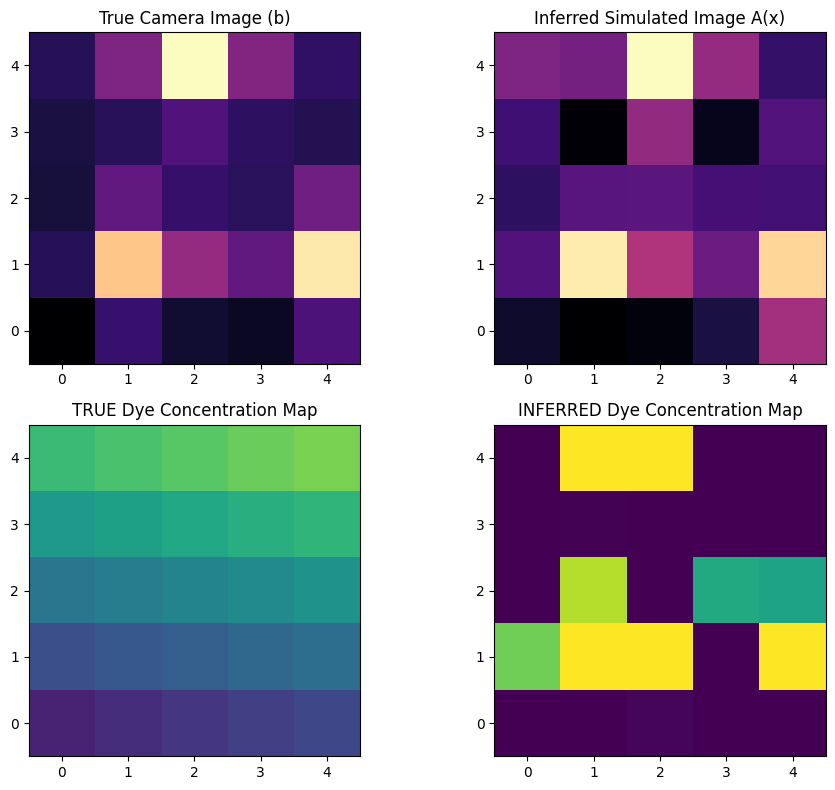

In [25]:
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. DUMMY FORWARD MODEL (2D Grid)
# ==========================================
def dummy_forward_model(x, grid_size=5, n_particles=3):
    """
    Differentiable PyTorch map A taking 31D state x to a 5x5 2D image b.
    """
    # Unpack the state vector
    pos_x = x[0:n_particles]
    pos_y = x[n_particles:2*n_particles]
    # Reshape the remaining 25 values into a 5x5 grid for dye concentrations
    concentrations = x[2*n_particles:].view(grid_size, grid_size)
    
    # Initialize a blank 2D camera image
    image_b = torch.zeros((grid_size, grid_size), dtype=torch.float32)
    
    # --- 1. Dye Contribution ---
    # The brief notes light intensity is not a straightforward function of dye[cite: 17].
    # We use a non-linear sqrt function, keeping values positive.
    dye_light = torch.sqrt(torch.abs(concentrations) + 1e-6) * 0.8
    image_b = image_b + dye_light
    
    # --- 2. Particle Contribution ---
    # Create a 2D coordinate grid to calculate particle light spread
    gy, gx = torch.meshgrid(torch.arange(grid_size, dtype=torch.float32), 
                            torch.arange(grid_size, dtype=torch.float32), indexing='ij')
    
    for px, py in zip(pos_x, pos_y):
        # 2D Gaussian spread simulating laser light reflecting off particles
        spread = torch.exp(-0.5 * (((gx - px) / 0.6)**2 + ((gy - py) / 0.6)**2))
        image_b = image_b + (spread * 2.0) # Particles appear as bright spots
        
    return image_b

# ==========================================
# 2. POTENTIAL ENERGY & LEAPFROG
# ==========================================
def potential_energy(x, target_image_b, grid_size=5, n_particles=3):
    simulated_image = dummy_forward_model(x, grid_size, n_particles)
    # Minimizing ||A(x) - b||_2
    return torch.sum((simulated_image - target_image_b)**2)

def leapfrog_step(x, p, epsilon, target_image_b, grid_size=5, n_particles=3):
    x.requires_grad_(True)
    U = potential_energy(x, target_image_b, grid_size, n_particles)
    grad_U = torch.autograd.grad(U, x)[0]
    
    p_half = p - (epsilon / 2) * grad_U
    x_new = x.detach() + epsilon * p_half
    x_new.requires_grad_(True)
    
    U_new = potential_energy(x_new, target_image_b, grid_size, n_particles)
    grad_U_new = torch.autograd.grad(U_new, x_new)[0]
    
    p_new = p_half - (epsilon / 2) * grad_U_new
    return x_new.detach(), p_new

# ==========================================
# 3. 2D VISUALIZATION FUNCTIONS
# ==========================================
def plot_2d_results(target_image, mean_x, true_x, grid_size=5, n_particles=3):
    guess_image = dummy_forward_model(mean_x, grid_size, n_particles).detach()
    inferred_dye = mean_x[2*n_particles:].view(grid_size, grid_size).detach()
    true_dye = true_x[2*n_particles:].view(grid_size, grid_size).detach() # NEW!
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # 2x2 Grid
    
    axes[0,0].imshow(target_image.tolist(), cmap='magma', origin='lower')
    axes[0,0].set_title("True Camera Image (b)")
    
    axes[0,1].imshow(guess_image.tolist(), cmap='magma', origin='lower')
    axes[0,1].set_title("Inferred Simulated Image A(x)")
    
    axes[1,0].imshow(true_dye.tolist(), cmap='viridis', origin='lower', vmin=0, vmax=1)
    axes[1,0].set_title("TRUE Dye Concentration Map")
    
    axes[1,1].imshow(inferred_dye.tolist(), cmap='viridis', origin='lower', vmin=0, vmax=1)
    axes[1,1].set_title("INFERRED Dye Concentration Map")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. THE MAIN HMC LOOP
# ==========================================
def run_hmc_2d(n_samples=800, leapfrog_steps=10, epsilon=0.005):
    grid_size = 5
    n_particles = 3
    
    # --- A. Generate Ground Truth (31 Dimensions) ---
    true_pos_x = torch.tensor([1.2, 4.0, 2.0])
    true_pos_y = torch.tensor([1.0, 1.0, 4.2])
    # Create a background dye concentration that varies slightly
    true_dye = torch.linspace(0.1, 0.8, grid_size*grid_size) 
    
    true_x = torch.cat((true_pos_x, true_pos_y, true_dye))
    target_image_b = dummy_forward_model(true_x, grid_size, n_particles).detach()
    
    # --- B. Initial Guess ---
    # guess_pos_x = torch.tensor([1.5, 3.0, 2.5])
    # guess_pos_y = torch.tensor([1.5, 3.5, 3.5])
    guess_pos_x = torch.tensor([2.5, 2.0, 2.5])
    guess_pos_y = torch.tensor([2.5, 2.5, 2.5])
    guess_dye = torch.ones(grid_size * grid_size) * 0.4
    current_x = torch.cat((guess_pos_x, guess_pos_y, guess_dye))
    
    samples = []
    accepted = 0
    
    print(f"Starting 2D HMC with {n_samples} samples...")
    
    for i in range(n_samples):
        current_p = torch.randn_like(current_x)
        x = current_x.clone()
        p = current_p.clone()
        
        H_current = potential_energy(current_x, target_image_b, grid_size, n_particles).item() + 0.5 * torch.sum(current_p**2).item()
        
        for _ in range(leapfrog_steps):
            x, p = leapfrog_step(x, p, epsilon, target_image_b, grid_size, n_particles)
            
        p = -p
        H_proposed = potential_energy(x, target_image_b, grid_size, n_particles).item() + 0.5 * torch.sum(p**2).item()
        
        # Metropolis Acceptance
        acceptance_prob = min(1.0, torch.exp(torch.tensor(H_current - H_proposed)).item())
        if torch.rand(1).item() < acceptance_prob:
            current_x = x
            accepted += 1
            
        samples.append(current_x.clone())
        
        if (i + 1) % 100 == 0:
            print(f"Sample {i+1}/{n_samples} | Acceptance Rate: {accepted/(i+1):.2f}")
            
    print("\nHMC Complete.")
    
    # Calculate Mean of Posterior (discarding first 200 as burn-in)
    samples_tensor = torch.stack(samples[200:])
    mean_estimate = torch.mean(samples_tensor, dim=0)
    
    plot_2d_results(target_image_b, mean_estimate, true_x, grid_size, n_particles)
    return samples

if __name__ == "__main__":
    # Note: epsilon is smaller here because 31 dimensions makes the probability 
    # landscape much steeper and harder to navigate than the previous 6 dimensions.
    samples = run_hmc_2d(n_samples=800, leapfrog_steps=10, epsilon=0.2)